# Human-in-the-Loop Stock Buying Chatbot

This notebook builds a small LangGraph chatbot with the standard tool-calling loop:

`START -> chatbot -> tools -> chatbot -> END`

The chatbot is a real LLM with two tools:

- `lookup_price`: returns a fixed demo stock price. No approval needed.
- `buy_stock`: validates cash balance, pauses for human approval, then updates the simulated account.

There is no selling in this demo. Keeping only lookup and buy makes the human-in-the-loop (HITL) approval boundary easier to see.

This is not financial advice. Prices are fixed constants, trades are simulated, and no brokerage API is used.

## Environment setup

This notebook uses Groq for the LLM chatbot, matching the other LangGraph examples in this repository. Add `GROQ_API_KEY` to `.env` before running it.

Important: LangGraph `interrupt(...)` pauses the graph and returns an `__interrupt__` value. In a plain notebook it does not automatically open a pop-up approval dialog. The notebook prints the approval request, then resumes the graph in the next cell with an explicit approval decision.

In [1]:
from __future__ import annotations

import copy
import os
import sys
from typing import Annotated, Any, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.types import Command, interrupt

load_dotenv()

assert os.getenv("GROQ_API_KEY"), "Add GROQ_API_KEY to your .env file."

print(f"Python executable: {sys.executable}")


/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/bin/python3


## Demo account and fixed prices

The account starts with cash and no positions. Prices are constants so the example is reproducible.

In [2]:
STOCK_PRICES = {
    "AAPL": 210.25,
    "MSFT": 450.50,
    "NVDA": 125.75,
}

STARTING_CASH_BALANCE = 1_000.00
STARTING_POSITIONS = {"AAPL": 0, "MSFT": 0, "NVDA": 0}


def normalize_symbol(symbol: str) -> str:
    normalized = symbol.upper().strip()
    if normalized not in STOCK_PRICES:
        supported = ", ".join(sorted(STOCK_PRICES))
        raise ValueError(f"Unsupported symbol '{symbol}'. Use one of: {supported}.")
    return normalized


def format_money(amount: float) -> str:
    return f"${amount:,.2f}"


print("Demo prices:")
for symbol, price in STOCK_PRICES.items():
    print(f"- {symbol}: {format_money(price)}")

print(f"Starting cash: {format_money(STARTING_CASH_BALANCE)}")
print(f"Starting positions: {STARTING_POSITIONS}")


Demo prices:
- AAPL: $210.25
- MSFT: $450.50
- NVDA: $125.75
Starting cash: $1,000.00
Starting positions: {'AAPL': 0, 'MSFT': 0, 'NVDA': 0}


## Define tool schemas

The LLM sees these two tools. The actual execution happens in our custom `tools` node so the buy tool can validate cash and request human approval before changing state.

In [3]:
@tool
def lookup_price(symbol: str) -> str:
    """Look up the fixed demo price for AAPL, MSFT, or NVDA."""
    return "Tool schema only; execution is handled by the LangGraph tools node."


@tool
def buy_stock(symbol: str, quantity: int) -> str:
    """Buy a whole-number quantity of AAPL, MSFT, or NVDA after human approval."""
    return "Tool schema only; execution is handled by the LangGraph tools node."


TOOLS = [lookup_price, buy_stock]

for current_tool in TOOLS:
    print(f"Tool: {current_tool.name}")
    print(f"Args: {current_tool.args}")


Tool: lookup_price
Args: {'symbol': {'title': 'Symbol', 'type': 'string'}}
Tool: buy_stock
Args: {'symbol': {'title': 'Symbol', 'type': 'string'}, 'quantity': {'title': 'Quantity', 'type': 'integer'}}


## Define graph state

Messages use `add_messages` because this is a normal chatbot/tool loop. Account fields are updated only by the custom `tools` node after approval.

In [4]:
class TradingState(TypedDict, total=False):
    messages: Annotated[list[BaseMessage], add_messages]
    cash_balance: float
    positions: dict[str, int]
    buy_history: list[dict[str, Any]]


## Chatbot node

The chatbot decides whether to call `lookup_price`, call `buy_stock`, or answer directly. After a tool result comes back, the chatbot summarizes it without calling another tool.

In [5]:
base_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
tool_calling_llm = base_llm.bind_tools(TOOLS)

SYSTEM_MESSAGE = SystemMessage(
    content=(
        "You are a stock-buying chatbot for a tutorial. Supported symbols are AAPL, MSFT, and NVDA. "
        "Use lookup_price for price or quote questions. Use buy_stock for buy requests. "
        "There is no sell tool in this demo. If the user asks to sell, say this demo only supports buying. "
        "Do not claim a purchase happened until the buy_stock tool result says it was executed. "
        "Keep final answers concise."
    )
)

FINAL_RESPONSE_MESSAGE = SystemMessage(
    content=(
        "You are summarizing a tool result for the user. Do not call tools. "
        "Report the result clearly and concisely."
    )
)


def chatbot(state: TradingState) -> dict[str, list[BaseMessage]]:
    last_message = state["messages"][-1]
    if isinstance(last_message, ToolMessage):
        response = base_llm.invoke([FINAL_RESPONSE_MESSAGE, *state["messages"]])
    else:
        response = tool_calling_llm.invoke([SYSTEM_MESSAGE, *state["messages"]])
    return {"messages": [response]}


## Tools node with HITL approval

`lookup_price` returns immediately. `buy_stock` validates the account balance, then calls `interrupt(...)` before any account state is changed.

In this notebook, the approval request appears as the `__interrupt__` value printed in the demo cell. A real application would connect that interrupt to a UI, Slack approval, admin console, or another review workflow.

In [6]:
def make_tool_message(tool_call: dict[str, Any], content: str) -> ToolMessage:
    return ToolMessage(
        content=content,
        name=tool_call["name"],
        tool_call_id=tool_call["id"],
    )


def validate_quantity(raw_quantity: Any) -> int:
    quantity = int(raw_quantity)
    if quantity <= 0:
        raise ValueError("Quantity must be a positive whole number.")
    return quantity


def tools(state: TradingState) -> dict[str, Any]:
    last_message = state["messages"][-1]
    if not isinstance(last_message, AIMessage) or not last_message.tool_calls:
        return {}

    tool_messages: list[ToolMessage] = []
    state_updates: dict[str, Any] = {}

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        args = tool_call.get("args", {})

        try:
            symbol = normalize_symbol(args["symbol"])
            price = STOCK_PRICES[symbol]

            if tool_name == "lookup_price":
                tool_messages.append(
                    make_tool_message(tool_call, f"{symbol} is {format_money(price)} in the fixed demo price table.")
                )
                continue

            if tool_name != "buy_stock":
                tool_messages.append(make_tool_message(tool_call, f"Unknown tool: {tool_name}"))
                continue

            quantity = validate_quantity(args["quantity"])
            trade_value = round(quantity * price, 2)
            cash_balance = state.get("cash_balance", 0.0)
            positions = copy.deepcopy(state.get("positions", {}))

            if trade_value > cash_balance:
                tool_messages.append(
                    make_tool_message(
                        tool_call,
                        (
                            f"Buy rejected before approval: buying {quantity} {symbol} costs "
                            f"{format_money(trade_value)}, but cash balance is {format_money(cash_balance)}."
                        ),
                    )
                )
                continue

            approval = interrupt(
                {
                    "message": "Approve this simulated stock purchase?",
                    "tool": "buy_stock",
                    "symbol": symbol,
                    "quantity": quantity,
                    "price": price,
                    "estimated_cost": trade_value,
                    "cash_balance": cash_balance,
                    "positions": positions,
                }
            )

            if isinstance(approval, dict):
                approved = bool(approval.get("approved", False))
                reviewer = str(approval.get("reviewer", "unknown"))
            else:
                approved = bool(approval)
                reviewer = "unknown"

            if not approved:
                tool_messages.append(
                    make_tool_message(
                        tool_call,
                        f"{reviewer} rejected the simulated purchase. Cash and positions were not changed.",
                    )
                )
                continue

            updated_cash = round(cash_balance - trade_value, 2)
            positions[symbol] = positions.get(symbol, 0) + quantity
            buy_record = {
                "symbol": symbol,
                "quantity": quantity,
                "price": price,
                "cost": trade_value,
                "approved_by": reviewer,
            }
            state_updates.update(
                {
                    "cash_balance": updated_cash,
                    "positions": positions,
                    "buy_history": [*state.get("buy_history", []), buy_record],
                }
            )
            tool_messages.append(
                make_tool_message(
                    tool_call,
                    (
                        f"{reviewer} approved the simulated purchase. Bought {quantity} {symbol} "
                        f"at {format_money(price)} for {format_money(trade_value)}."
                    ),
                )
            )
        except (KeyError, TypeError, ValueError) as error:
            tool_messages.append(make_tool_message(tool_call, f"Tool error: {error}"))

    return {"messages": tool_messages, **state_updates}


## Compile the graph

The graph has only two runtime nodes:

```text
START -> chatbot
chatbot -> tools, when the LLM requested a tool
chatbot -> END, when the LLM produced a final answer
tools -> chatbot, so the LLM can summarize tool results
```

The checkpointer is required because `interrupt(...)` pauses and resumes a thread.

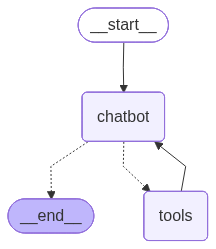

In [7]:
def route_after_chatbot(state: TradingState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tools"
    return END


builder = StateGraph(TradingState)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tools)

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", route_after_chatbot, {"tools": "tools", END: END})
builder.add_edge("tools", "chatbot")

graph = builder.compile(checkpointer=InMemorySaver())
graph


## Demo helpers

Each demo uses a separate `thread_id`, which keeps interrupted graph runs separate from each other.

In [8]:
def initial_state(user_text: str) -> TradingState:
    return {
        "messages": [HumanMessage(content=user_text)],
        "cash_balance": STARTING_CASH_BALANCE,
        "positions": copy.deepcopy(STARTING_POSITIONS),
        "buy_history": [],
    }


def config_for(thread_id: str) -> dict[str, Any]:
    return {"configurable": {"thread_id": thread_id}}


def latest_ai_text(state: TradingState) -> str:
    for message in reversed(state.get("messages", [])):
        if isinstance(message, AIMessage) and not message.tool_calls:
            return str(message.content)
    return ""


def print_result(label: str, state: TradingState) -> None:
    print(f"\n--- {label} ---")
    if "__interrupt__" in state:
        print("APPROVAL REQUEST RETURNED BY LangGraph interrupt(...):")
        print(state["__interrupt__"][0].value)
        print("Resume this same thread with Command(resume={...}) to approve or reject.")
        return

    print(latest_ai_text(state))
    print(f"Cash: {format_money(state.get('cash_balance', 0))}")
    print(f"Positions: {state.get('positions', {})}")
    print(f"Buy history: {state.get('buy_history', [])}")


def tool_names_from_state(state: TradingState) -> list[str]:
    names: list[str] = []
    for message in state.get("messages", []):
        if isinstance(message, AIMessage) and message.tool_calls:
            names.extend(tool_call["name"] for tool_call in message.tool_calls)
    return names


## Demo 1: price lookup does not need approval

The chatbot requests `lookup_price`, the tools node returns the fixed price, and the chatbot summarizes the result.

In [9]:
quote_state = graph.invoke(
    initial_state("What is NVDA trading at?"),
    config=config_for("quote-demo"),
)

print_result("Quote flow", quote_state)

assert "__interrupt__" not in quote_state
assert "lookup_price" in tool_names_from_state(quote_state)
assert quote_state["cash_balance"] == STARTING_CASH_BALANCE
assert quote_state["positions"] == STARTING_POSITIONS
assert quote_state["buy_history"] == []



--- Quote flow ---
NVDA is trading at $125.75.
Cash: $1,000.00
Positions: {'AAPL': 0, 'MSFT': 0, 'NVDA': 0}
Buy history: []


## Demo 2: buy request pauses for approval

The chatbot requests `buy_stock`. The tools node validates cash balance and then pauses before changing cash or positions.

This cell should print an approval request. It is the HITL handoff point.

In [10]:
buy_config = config_for("approved-buy-demo")
buy_interrupted_state = graph.invoke(
    initial_state("Buy 2 shares of AAPL."),
    config=buy_config,
)

print_result("Buy before approval", buy_interrupted_state)

assert "__interrupt__" in buy_interrupted_state
assert "buy_stock" in tool_names_from_state(buy_interrupted_state)
assert buy_interrupted_state["cash_balance"] == STARTING_CASH_BALANCE
assert buy_interrupted_state["positions"] == STARTING_POSITIONS
approval_payload = buy_interrupted_state["__interrupt__"][0].value
assert approval_payload["tool"] == "buy_stock"
assert approval_payload["symbol"] == "AAPL"
assert approval_payload["quantity"] == 2



--- Buy before approval ---
APPROVAL REQUEST RETURNED BY LangGraph interrupt(...):
{'message': 'Approve this simulated stock purchase?', 'tool': 'buy_stock', 'symbol': 'AAPL', 'quantity': 2, 'price': 210.25, 'estimated_cost': 420.5, 'cash_balance': 1000.0, 'positions': {'AAPL': 0, 'MSFT': 0, 'NVDA': 0}}
Resume this same thread with Command(resume={...}) to approve or reject.


## Demo 3: resume with approval

In a real app, this resume command would be triggered by a human approval UI. In this notebook, we simulate the reviewer decision explicitly so the notebook can execute end to end.

In [11]:
approved_buy_state = graph.invoke(
    Command(resume={"approved": True, "reviewer": "demo_user"}),
    config=buy_config,
)

print_result("Buy after approval", approved_buy_state)

expected_cash = round(STARTING_CASH_BALANCE - 2 * STOCK_PRICES["AAPL"], 2)
assert "__interrupt__" not in approved_buy_state
assert approved_buy_state["cash_balance"] == expected_cash
assert approved_buy_state["positions"]["AAPL"] == STARTING_POSITIONS["AAPL"] + 2
assert len(approved_buy_state["buy_history"]) == 1
assert approved_buy_state["buy_history"][0]["approved_by"] == "demo_user"



--- Buy after approval ---
You have successfully bought 2 shares of AAPL at $210.25 per share, totaling $420.50.
Cash: $579.50
Positions: {'AAPL': 2, 'MSFT': 0, 'NVDA': 0}
Buy history: [{'symbol': 'AAPL', 'quantity': 2, 'price': 210.25, 'cost': 420.5, 'approved_by': 'demo_user'}]


## Demo 4: insufficient cash rejects before approval

This request cannot be approved because the account does not have enough cash. The tools node rejects it before interrupting.

In [12]:
invalid_buy_state = graph.invoke(
    initial_state("Buy 10 shares of MSFT."),
    config=config_for("invalid-buy-demo"),
)

print_result("Invalid buy", invalid_buy_state)

assert "__interrupt__" not in invalid_buy_state
assert "buy_stock" in tool_names_from_state(invalid_buy_state)
assert invalid_buy_state["cash_balance"] == STARTING_CASH_BALANCE
assert invalid_buy_state["positions"] == STARTING_POSITIONS
assert invalid_buy_state["buy_history"] == []



--- Invalid buy ---
Your request to buy 10 shares of MSFT has been rejected due to insufficient funds. The total cost of the purchase would be $4,505.00, but your current cash balance is only $1,000.00.
Cash: $1,000.00
Positions: {'AAPL': 0, 'MSFT': 0, 'NVDA': 0}
Buy history: []


## Key takeaways

- The graph has the intuitive chatbot/tools loop: `chatbot -> tools -> chatbot`.
- The LLM decides whether to call `lookup_price` or `buy_stock`.
- `lookup_price` is informational and returns immediately.
- `buy_stock` validates cash and pauses with `interrupt(...)` before updating account state.
- In a notebook, `interrupt(...)` returns an approval payload; an application must connect that pause to a real human review UI.